# Chapter 18 — Simple Linear Regression

## Learning Objectives

By the end of this chapter, you will be able to:

- Explain the purpose of simple linear regression
- Distinguish an outcome variable from a predictor variable
- Interpret the intercept and slope of a regression line
- Understand fitted values and residuals
- Explain the least-squares principle
- Connect covariance, correlation, and the regression slope
- Fit a regression model with Python
- Interpret $R^2$
- Interpret confidence intervals and hypothesis tests for the slope
- Examine residual plots and recognize important limitations
- Distinguish association, prediction, and causation


## 1. From Correlation to Regression

In Chapter 17, Pearson's correlation coefficient summarized the **direction and strength of a linear relationship**.

Regression asks a different question:

> How does an outcome variable tend to change as a predictor variable changes?

For this chapter:

- $X$ = training hours
- $Y$ = performance score

We will use training hours to model performance score.


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm

def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "data").is_dir():
            return candidate
    raise FileNotFoundError("Could not find the project root containing a data/ directory.")

ROOT = find_project_root(Path.cwd())
DATA_PATH = ROOT / "data" / "18_simple_linear_regression.csv"

df = pd.read_csv(DATA_PATH)
df.head()


,employee_id,training_hours,performance_score
0,E001,7.9,84.4
1,E002,3.1,64.6
2,E003,9.0,74.9
3,E004,1.5,44.5
4,E005,5.4,75.9


## 2. Dataset

The dataset contains **80 fictional employees**.

| Variable | Description |
|---|---|
| `employee_id` | Fictional employee identifier |
| `training_hours` | Training hours |
| `performance_score` | Performance assessment score |

All data are synthetic and are used only for statistical learning.


In [3]:
df.describe()


,training_hours,performance_score
count,80.000000,80.000000
mean,6.046250,71.988750
std,3.386232,13.223215
min,0.500000,44.500000
25%,3.100000,62.700000
50%,6.050000,72.300000
75%,8.925000,82.250000
max,12.000000,100.000000


## 3. Start with a Scatter Plot

Before fitting a model, inspect the relationship visually.


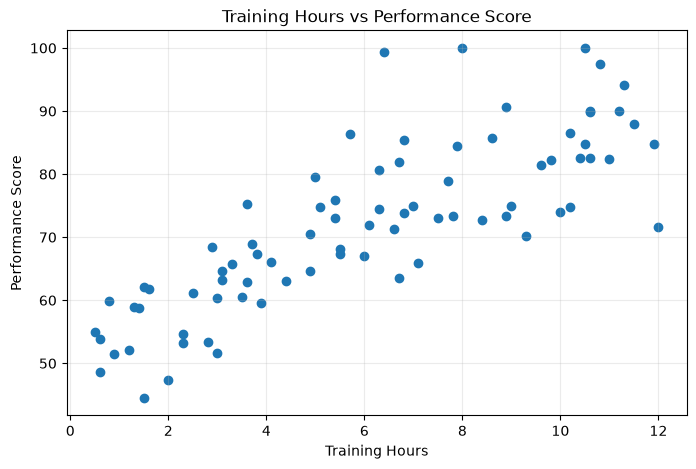

In [4]:
plt.figure(figsize=(8, 5))
plt.scatter(df["training_hours"], df["performance_score"])
plt.xlabel("Training Hours")
plt.ylabel("Performance Score")
plt.title("Training Hours vs Performance Score")
plt.grid(alpha=0.25)
plt.show()


The scatter plot suggests that a straight line may be a useful summary of the relationship.

A regression model formalizes that line.


## 4. The Simple Linear Regression Model

The population model is

$$
Y = \beta_0 + \beta_1 X + \varepsilon
$$

where:

- $Y$ is the outcome variable
- $X$ is the predictor variable
- $\beta_0$ is the population intercept
- $\beta_1$ is the population slope
- $\varepsilon$ represents variation not explained by the linear relationship

Because the population parameters are usually unknown, we estimate them from a sample.


The fitted regression line is

$$
\hat{Y} = b_0 + b_1 X
$$

where:

- $\hat{Y}$ is the fitted or predicted value
- $b_0$ is the estimated intercept
- $b_1$ is the estimated slope


## 5. Interpreting the Slope and Intercept

The slope $b_1$ describes the estimated change in the outcome associated with a one-unit increase in the predictor.

For example, if

$$
b_1 = 3
$$

then one additional training hour is associated with an estimated **3-point increase** in performance score, on average.

The intercept $b_0$ is the predicted value of $Y$ when $X=0$.

An intercept can be mathematically necessary even when $X=0$ is outside the observed data or has little practical meaning.


## 6. Estimate the Regression Line Manually

The least-squares slope can be written as

$$
b_1 =
\frac{\sum_{i=1}^{n}(x_i-\bar{x})(y_i-\bar{y})}
{\sum_{i=1}^{n}(x_i-\bar{x})^2}
$$

Using sample covariance and variance,

$$
b_1 =
\frac{s_{XY}}{s_X^2}
$$

The intercept is

$$
b_0 = \bar{y} - b_1\bar{x}
$$


In [5]:
x = df["training_hours"]
y = df["performance_score"]

cov_xy = x.cov(y)
var_x = x.var(ddof=1)

b1 = cov_xy / var_x
b0 = y.mean() - b1 * x.mean()

print("Estimated intercept:", b0)
print("Estimated slope:", b1)


Estimated intercept: 52.72636365405151
Estimated slope: 3.185840206069627


## 7. Covariance → Correlation → Regression

From Chapter 17,

$$
r = \frac{s_{XY}}{s_X s_Y}
$$

Therefore,

$$
s_{XY} = r s_X s_Y
$$

Substituting this into the slope formula gives

$$
b_1
=
\frac{s_{XY}}{s_X^2}
=
r\frac{s_Y}{s_X}
$$

This connects the three chapters:

$$
\text{Covariance}
\rightarrow
\text{Correlation}
\rightarrow
\text{Regression}
$$


In [6]:
r = x.corr(y)
s_x = x.std(ddof=1)
s_y = y.std(ddof=1)

slope_from_r = r * (s_y / s_x)

print("Slope from covariance:", b1)
print("Slope from correlation:", slope_from_r)
print("Same result:", np.isclose(b1, slope_from_r))


Slope from covariance: 3.185840206069627
Slope from correlation: 3.185840206069626
Same result: True


## 8. Fitted Values

For each observation, the regression line produces a fitted value:

$$
\hat{y}_i = b_0 + b_1x_i
$$


In [7]:
df["fitted_score"] = b0 + b1 * df["training_hours"]

df[
    ["employee_id", "training_hours", "performance_score", "fitted_score"]
].head()


,employee_id,training_hours,performance_score,fitted_score
0,E001,7.9,84.4,77.894501
1,E002,3.1,64.6,62.602468
2,E003,9.0,74.9,81.398926
3,E004,1.5,44.5,57.505124
4,E005,5.4,75.9,69.929901


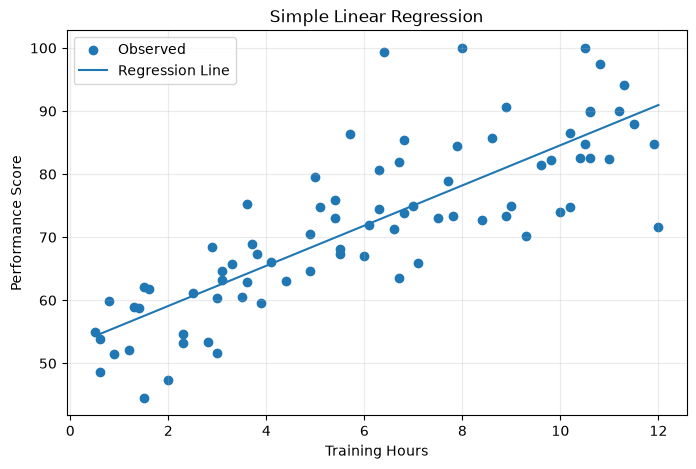

In [8]:
x_line = np.linspace(df["training_hours"].min(), df["training_hours"].max(), 100)
y_line = b0 + b1 * x_line

plt.figure(figsize=(8, 5))
plt.scatter(df["training_hours"], df["performance_score"], label="Observed")
plt.plot(x_line, y_line, label="Regression Line")
plt.xlabel("Training Hours")
plt.ylabel("Performance Score")
plt.title("Simple Linear Regression")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## 9. Residuals

A residual is the difference between an observed value and its fitted value:

$$
e_i = y_i - \hat{y}_i
$$

Residuals represent the part of the observed outcome that the fitted line does not explain.


In [9]:
df["residual"] = df["performance_score"] - df["fitted_score"]

df[
    ["employee_id", "performance_score", "fitted_score", "residual"]
].head()


,employee_id,performance_score,fitted_score,residual
0,E001,84.4,77.894501,6.505499
1,E002,64.6,62.602468,1.997532
2,E003,74.9,81.398926,-6.498926
3,E004,44.5,57.505124,-13.005124
4,E005,75.9,69.929901,5.970099


A positive residual means the observed value is above the fitted line.

A negative residual means the observed value is below the fitted line.


## 10. Why This Line? The Least-Squares Principle

There are many possible straight lines.

Ordinary least squares chooses the line that minimizes the **sum of squared residuals**:

$$
SSE = \sum_{i=1}^{n}(y_i-\hat{y}_i)^2
$$

Squaring prevents positive and negative residuals from canceling and penalizes larger errors more strongly.


In [10]:
sse = np.sum(df["residual"] ** 2)
sse


np.float64(4619.334730509208)

## 11. Fit the Model with statsmodels

Now fit the same model using `statsmodels`.

`statsmodels` does not automatically add the intercept column, so we add a constant explicitly.


In [11]:
X = sm.add_constant(df["training_hours"])
model = sm.OLS(df["performance_score"], X).fit()

model.params


const             52.726364
training_hours     3.185840
dtype: float64

In [12]:
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:      performance_score   R-squared:                       0.666
Model:                            OLS   Adj. R-squared:                  0.661
Method:                 Least Squares   F-statistic:                     155.2
Date:                Sun, 20 Sep 2026   Prob (F-statistic):           3.07e-20
Time:                        16:03:22   Log-Likelihood:                -275.75
No. Observations:                  80   AIC:                             555.5
Df Residuals:                      78   BIC:                             560.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             52.7264      1.769     29.

The estimated coefficients from `statsmodels` should match the manual calculations.

In the output:

- `const` is the estimated intercept
- `training_hours` is the estimated slope


## 12. Interpreting the Estimated Model

Write the fitted model as

$$
\widehat{\text{Performance}}
=
b_0
+
b_1(\text{Training Hours})
$$

Use the actual estimated coefficients from the model output.

The slope should be interpreted as an **estimated average change in the outcome associated with a one-unit increase in the predictor**.

Avoid automatically turning this association into a causal claim.


In [13]:
print(
    f"Estimated model: Performance Score = "
    f"{model.params['const']:.2f} + "
    f"{model.params['training_hours']:.2f} × Training Hours"
)


Estimated model: Performance Score = 52.73 + 3.19 × Training Hours


## 13. Decomposing Variation

Regression separates variation in $Y$ into explained and unexplained components.

The total sum of squares is

$$
SST = \sum_{i=1}^{n}(y_i-\bar{y})^2
$$

The regression sum of squares is

$$
SSR = \sum_{i=1}^{n}(\hat{y}_i-\bar{y})^2
$$

The error sum of squares is

$$
SSE = \sum_{i=1}^{n}(y_i-\hat{y}_i)^2
$$

For ordinary least squares with an intercept,

$$
SST = SSR + SSE
$$


In [14]:
y_mean = y.mean()

sst = np.sum((y - y_mean) ** 2)
ssr = np.sum((df["fitted_score"] - y_mean) ** 2)
sse = np.sum(df["residual"] ** 2)

print("SST:", sst)
print("SSR:", ssr)
print("SSE:", sse)
print("SSR + SSE:", ssr + sse)
print("Identity holds:", np.isclose(sst, ssr + sse))


SST: 13813.419875000001
SSR: 9194.085144490793
SSE: 4619.334730509208
SSR + SSE: 13813.419875000001
Identity holds: True


## 14. Coefficient of Determination: $R^2$

The coefficient of determination is

$$
R^2
=
\frac{SSR}{SST}
=
1-\frac{SSE}{SST}
$$

It describes the proportion of observed variation in the outcome accounted for by the fitted linear model in the sample.


In [15]:
r_squared_manual = 1 - sse / sst

print("Manual R²:", r_squared_manual)
print("statsmodels R²:", model.rsquared)


Manual R²: 0.6655907970429946
statsmodels R²: 0.6655907970429944


In simple linear regression with an intercept and one predictor,

$$
R^2 = r^2
$$

where $r$ is the Pearson correlation between $X$ and $Y$.


In [16]:
print("R²:", model.rsquared)
print("Pearson r²:", r ** 2)
print("Same result:", np.isclose(model.rsquared, r ** 2))


R²: 0.6655907970429944
Pearson r²: 0.6655907970429944
Same result: True


## 15. Inference for the Slope

A common hypothesis test for the population slope is

$$
H_0:\beta_1=0
$$

versus

$$
H_1:\beta_1\ne0
$$

The test statistic is

$$
t =
\frac{b_1-0}{SE(b_1)}
$$

The p-value evaluates how compatible the observed slope is with a population slope of zero under the model assumptions.


In [17]:
slope = model.params["training_hours"]
slope_se = model.bse["training_hours"]
slope_t = model.tvalues["training_hours"]
slope_p = model.pvalues["training_hours"]

print("Slope:", slope)
print("Standard error:", slope_se)
print("t statistic:", slope_t)
print("p-value:", slope_p)


Slope: 3.185840206069626
Standard error: 0.25568905830186045
t statistic: 12.459822204470315
p-value: 3.069450815651337e-20


A small p-value provides evidence against a zero population slope under the assumptions of the model.

It does **not** establish causation, and it does not by itself tell us whether the association is practically important.


## 16. Confidence Interval for the Slope

A confidence interval gives a range of plausible values for the population slope under the model assumptions.


In [18]:
model.conf_int().loc["training_hours"]


0    2.676802
1    3.694878
Name: training_hours, dtype: float64

Interpret the interval in the units of the variables.

For this dataset, the slope represents the estimated change in **performance-score points per additional training hour**.


## 17. Residual Diagnostics

A useful regression model should not be judged only by its coefficient or $R^2$.

Residuals help us examine whether the linear model is behaving reasonably.


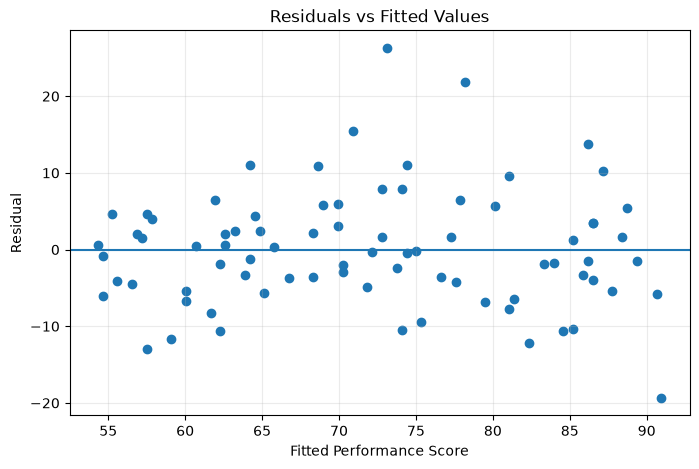

In [19]:
plt.figure(figsize=(8, 5))
plt.scatter(df["fitted_score"], df["residual"])
plt.axhline(0)
plt.xlabel("Fitted Performance Score")
plt.ylabel("Residual")
plt.title("Residuals vs Fitted Values")
plt.grid(alpha=0.25)
plt.show()


For a simple linear model, we generally look for residuals that fluctuate around zero without an obvious systematic pattern.

Patterns may suggest problems such as:

- nonlinearity
- changing residual spread
- unusual observations
- missing structure in the model


## 18. Distribution of Residuals


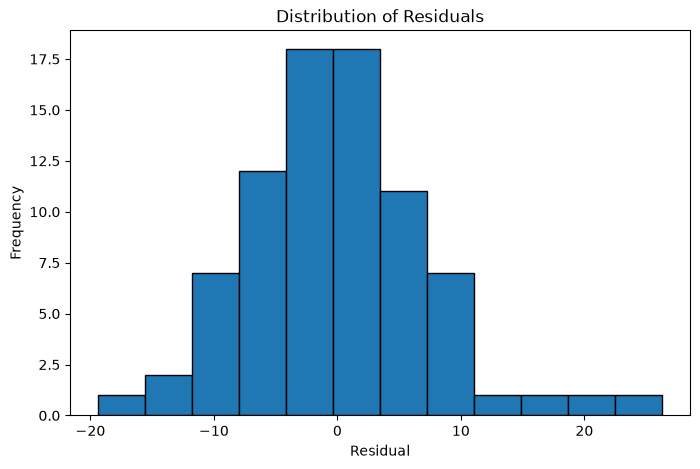

In [20]:
plt.figure(figsize=(8, 5))
plt.hist(df["residual"], bins=12, edgecolor="black")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")
plt.show()


Normality of residuals is especially relevant to the usual small-sample inference procedures for regression coefficients.

A histogram is only a basic diagnostic; it should not be treated as a mechanical pass/fail test.


## 19. Important Assumptions and Conditions

For the usual simple linear regression inference, important considerations include:

1. **Linearity** — the mean relationship between $X$ and $Y$ is appropriately represented by a line.
2. **Independence** — observations or errors are appropriately independent for the study design.
3. **Constant variance** — the spread of residuals is reasonably stable across fitted values.
4. **Approximately normal errors for classical small-sample inference** — especially relevant for confidence intervals and hypothesis tests.
5. **No highly influential observations dominating the result**.

The appropriate diagnostics depend on the data-generating process and research design.


## 20. Prediction

Once a regression model has been fitted, it can produce a predicted mean response for a chosen predictor value.

Suppose we want the fitted performance score at 8 training hours.


In [21]:
new_x = pd.DataFrame({
    "const": [1.0],
    "training_hours": [8.0]
})

model.predict(new_x)


0    78.213085
dtype: float64

A fitted value is not a guarantee for an individual observation.

Individual outcomes still vary around the regression line.


## 21. Mean-Response Confidence Interval vs Prediction Interval

These two intervals answer different questions:

- **Confidence interval for the mean response:** uncertainty about the average outcome at a given $X$
- **Prediction interval:** uncertainty for a new individual outcome at a given $X$

Prediction intervals are wider because they include both uncertainty about the mean relationship and individual-level variation.


In [22]:
prediction = model.get_prediction(new_x).summary_frame(alpha=0.05)
prediction


,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,78.213085,0.994902,76.232387,80.193784,62.764821,93.661349


In the `statsmodels` output:

- `mean_ci_lower` and `mean_ci_upper` form the confidence interval for the mean response
- `obs_ci_lower` and `obs_ci_upper` form the prediction interval for a new observation


## 22. Avoid Extrapolation

The model was estimated from a specific observed range of training hours.

Predictions far outside that range are **extrapolations**.

A linear pattern observed within the sample range does not guarantee that the same relationship continues indefinitely.


In [23]:
print(
    "Observed training-hour range:",
    df["training_hours"].min(),
    "to",
    df["training_hours"].max()
)


Observed training-hour range: 0.5 to 12.0


## 23. Regression Does Not Automatically Establish Causation

A positive regression slope means that larger values of $X$ are associated with larger fitted values of $Y$ in the model.

It does not by itself prove that changing $X$ causes $Y$ to change.

Possible issues include:

- confounding variables
- reverse causality
- selection effects
- measurement problems
- model misspecification

Causal interpretation requires appropriate study design and assumptions beyond ordinary regression output.


## 24. A Practical Simple Regression Workflow

$$
\text{Define } X \text{ and } Y
\rightarrow
\text{Inspect Scatter Plot}
\rightarrow
\text{Fit Regression Line}
\rightarrow
\text{Interpret Slope}
\rightarrow
\text{Evaluate } R^2
\rightarrow
\text{Check Residuals}
\rightarrow
\text{Use Inference Carefully}
\rightarrow
\text{Avoid Unsupported Causal Claims}
$$


## 25. Exercises

### Exercise 1
Calculate the regression slope and intercept manually using covariance and variance.

Verify the result with `statsmodels`.

### Exercise 2
Explain the slope in the units of this dataset.

### Exercise 3
Calculate fitted values and residuals for the first five employees manually.

### Exercise 4
Verify that

$$
SST = SSR + SSE
$$

for this model.

### Exercise 5
Verify that

$$
R^2 = r^2
$$

for this simple linear regression model with an intercept.

### Exercise 6
Predict the mean performance score at 5 and 10 training hours.

Compare the mean-response confidence intervals and individual prediction intervals.

### Exercise 7
Create a residual-vs-fitted plot and describe whether you see an obvious systematic pattern.

### Exercise 8
Explain why predicting performance at 30 training hours would be questionable for this dataset.


## 26. Summary

Simple linear regression models the average linear relationship between one predictor and one outcome.

The population model is

$$
Y = \beta_0 + \beta_1X + \varepsilon
$$

and the fitted line is

$$
\hat{Y} = b_0 + b_1X
$$

Key relationships include

$$
b_1
=
\frac{s_{XY}}{s_X^2}
=
r\frac{s_Y}{s_X}
$$

and, for simple linear regression with an intercept,

$$
R^2=r^2
$$

Key ideas:

- the slope describes the estimated change in $Y$ associated with a one-unit increase in $X$
- residuals are observed values minus fitted values
- least squares minimizes the sum of squared residuals
- $R^2$ describes the proportion of sample variation accounted for by the fitted model
- slope inference uses standard errors, confidence intervals, and hypothesis tests
- residual diagnostics are essential
- prediction intervals are wider than confidence intervals for the mean response
- extrapolation should be treated cautiously
- regression does not automatically imply causation

### Next Chapter

**Chapter 19 — Multiple Linear Regression**

We will extend the model from one predictor to several predictors and examine how regression coefficients are interpreted while holding other predictors constant.
